In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import os
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
import os
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

print(" Todos los modulos importados correctamente")

 Todos los modulos importados correctamente


In [2]:
df = pd.read_csv("../Asistencia/Data/dataset_limpio.csv")

In [5]:

variables_a_eliminar = ['US_BoxOfficeUSD', 'Opening_Day_SalesUSD']
variables_a_eliminar = [var for var in variables_a_eliminar if var in df.columns]

if variables_a_eliminar:
    df = df.drop(columns=variables_a_eliminar)
    print(f" Variables eliminadas por redundancia: {variables_a_eliminar}")

nulos_totales = df.isnull().sum().sum()
if nulos_totales > 0:
    print(f"\nSe encontraron {nulos_totales} valores nulos")
    
    nulos_porcentaje = df.isnull().mean() * 100
    cols_muy_incompletas = nulos_porcentaje[nulos_porcentaje > 30].index
    
    if len(cols_muy_incompletas) > 0:
        df = df.drop(columns=cols_muy_incompletas)
        print(f"Columnas eliminadas (>30% nulos): {list(cols_muy_incompletas)}")
    
    # Imputar nulos restantes en columnas numericas
    for col in df.select_dtypes(include=['number']).columns:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
            print(f"    Nulos en '{col}' imputados con mediana")
else:
    print("No se encontraron valores nulos")

categorical_columns = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_columns) > 0:
    encoders = {}
    print(f"\n Codificando {len(categorical_columns)} variables categóricas:")
    
    for column in categorical_columns:
        unique_vals = df[column].nunique()
        
        if unique_vals <= 10:
            le = LabelEncoder()
            df[column] = le.fit_transform(df[column].astype(str))
            encoders[column] = le
            print(f"   • {column}: Label Encoding ({unique_vals} categorias)")
        else:
            # Frequency Encoding para alta cardinalidad
            freq_map = df[column].value_counts().to_dict()
            df[column + '_freq'] = df[column].map(freq_map)
            df = df.drop(columns=[column])
            print(f"   {column}: Frequency Encoding ({unique_vals} categorias → 1 columna)")
    
    print("Transformacion categorica completada")
else:
    print("No hay variables categoricas para codificar")

# 4. MANEJO DE OUTLIERS (basado en analisis EDA)
print(f"\n MANEJO DE OUTLIERS:")
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    if col not in ['MovieID', 'ReleaseYear']:  # Excluir IDs y años
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
        outliers_percent = (outliers_count / len(df)) * 100
        
        if outliers_percent > 5:  # Si mas del 5% son outliers
            print(f"   {col}: {outliers_count} outliers ({outliers_percent:.1f}%) - Considerar winsorization")
        else:
            print(f"   {col}: {outliers_count} outliers ({outliers_percent:.1f}%) - Mantener")

# 5. GUARDAR DATASET LIMPIO
os.makedirs('../Datos', exist_ok=True)
df.to_csv('../Asistencia/Data/dataset_limpio.csv', index=False)

# VERIFICACION FINAL
print(f"\n PROCESO COMPLETADO:")
print(f"   Archivo guardado: '../Datos/dataset_limpio.csv'")


No se encontraron valores nulos
No hay variables categoricas para codificar

 MANEJO DE OUTLIERS:
   Genre: 0 outliers (0.0%) - Mantener
   Country: 161270 outliers (22.4%) - Considerar winsorization
   BudgetUSD: 75006 outliers (10.4%) - Considerar winsorization
   Global_BoxOfficeUSD: 64880 outliers (9.0%) - Considerar winsorization
   One_Week_SalesUSD: 81583 outliers (11.3%) - Considerar winsorization
   IMDbRating: 78354 outliers (10.9%) - Considerar winsorization
   RottenTomatoesScore: 2697 outliers (0.4%) - Mantener
   ROI: 61289 outliers (8.5%) - Considerar winsorization
   ROI_Ratio: 61289 outliers (8.5%) - Considerar winsorization
   Categoria_Rentabilidad: 0 outliers (0.0%) - Mantener
   Quintil_Rentabilidad: 0 outliers (0.0%) - Mantener
   ReleaseDate_freq: 870 outliers (0.1%) - Mantener
   Director_freq: 0 outliers (0.0%) - Mantener
   LeadActor_freq: 4806 outliers (0.7%) - Mantener

 PROCESO COMPLETADO:
   Archivo guardado: '../Datos/dataset_limpio.csv'


In [6]:
df = pd.read_csv("../Asistencia/Data/dataset_limpio.csv")

In [7]:

# Identificar columnas numericas
num_cols = df.select_dtypes(include=['number']).columns

# Excluir columnas que no deberian ser normalizadas
exclude_cols = ['MovieID', 'ReleaseYear', 'ROI']  
cols_to_scale = [col for col in num_cols if col not in exclude_cols]

print(f"Columnas a normalizar ({len(cols_to_scale)}): {cols_to_scale}")
print(f"Columnas excluidas: {[col for col in num_cols if col not in cols_to_scale]}")

# Aplicar StandardScaler
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("\n Normalizacion completada")
print("Estadisticas despues de normalizacion (primeras 5 filas):")
display(df[cols_to_scale].head())

# Verificar que la media es ~0 y desviacion ~1
print("\n VERIFICACION DE NORMALIZACION:")
for col in cols_to_scale[:3]:  # Mostrar solo las 3 primeras 
    print(f"   {col}: media={df[col].mean():.3f}, std={df[col].std():.3f}")

Columnas a normalizar (13): ['Genre', 'Country', 'BudgetUSD', 'Global_BoxOfficeUSD', 'One_Week_SalesUSD', 'IMDbRating', 'RottenTomatoesScore', 'ROI_Ratio', 'Categoria_Rentabilidad', 'Quintil_Rentabilidad', 'ReleaseDate_freq', 'Director_freq', 'LeadActor_freq']
Columnas excluidas: ['MovieID', 'ReleaseYear', 'ROI']

 Normalizacion completada
Estadisticas despues de normalizacion (primeras 5 filas):


,Genre,Country,BudgetUSD,Global_BoxOfficeUSD,One_Week_SalesUSD,IMDbRating,RottenTomatoesScore,ROI_Ratio,Categoria_Rentabilidad,Quintil_Rentabilidad,ReleaseDate_freq,Director_freq,LeadActor_freq
0,-0.894881,-2.072891,-0.059335,0.076172,-0.245756,0.162132,-0.384302,-0.163611,1.171419,0.018483,-0.454096,-2.277853,-0.424751
1,-0.894881,0.534425,-0.575091,-0.559296,-0.447836,-0.279696,-1.179408,0.265967,-0.114228,1.405487,-1.701787,0.469983,0.349740
2,-0.894881,0.534425,-0.473464,-0.519770,-0.441683,0.648143,1.262703,-0.146645,1.171419,0.018483,0.258870,-0.450474,-0.633268
3,-0.435823,-0.955470,-0.517572,-0.587471,-0.445088,0.117949,0.126838,-0.135667,1.171419,0.711985,2.397769,-0.978384,-0.156658
4,0.023235,0.534425,-0.077205,-0.688411,-0.186343,1.355068,2.001016,-0.218283,0.528595,-1.368521,-1.880028,-0.572300,0.240517



 VERIFICACION DE NORMALIZACION:
   Genre: media=0.000, std=1.000
   Country: media=0.000, std=1.000
   BudgetUSD: media=-0.000, std=1.000


No se utilizaron tecnicas de reduccion dimensional como PCA o LDA porque el conjunto de datos tiene solo 13 caracteristicas, lo que se considera un volumen manejable y no se clasifica como alta dimensionalidad en el ambito del machine learning. Esta eleccion se basa en la necesidad de mantener la interpretabilidad de las variables originales, que tienen un significado comercial claro, y en evitar la perdida de informacion especifica que cada caracteristica aporta segun el analisis exploratorio. Ademas, no se encontro una alta redundancia entre las variables que justificara una reduccion drastica.

 Variables encontradas: ['BudgetUSD', 'One_Week_SalesUSD', 'IMDbRating', 'RottenTomatoesScore', 'Genre', 'Country', 'ReleaseYear', 'Global_BoxOfficeUSD']

2. DEFINIR VARIABLE OBJETIVO...
 Variable objetivo: ROI

3. DATOS DEFINIDOS:
   X (predictoras): (720471, 8)
   y (objetivo): (720471,)

4. LIMPIANDO DATOS...

5. DIVIDIENDO DATOS...
   • Train: 576376 muestras
   • Test: 144095 muestras
 Modelo entrenado exitosamente

 IMPORTANCIA DE CARACTERÍSTICAS:
   • One_Week_SalesUSD: 0.000
   • IMDbRating: 0.000
   • RottenTomatoesScore: 0.000
   • Genre: 0.000
   • ReleaseYear: 0.000
   • Country: 0.000
   • Global_BoxOfficeUSD: 0.416
   • BudgetUSD: 0.584


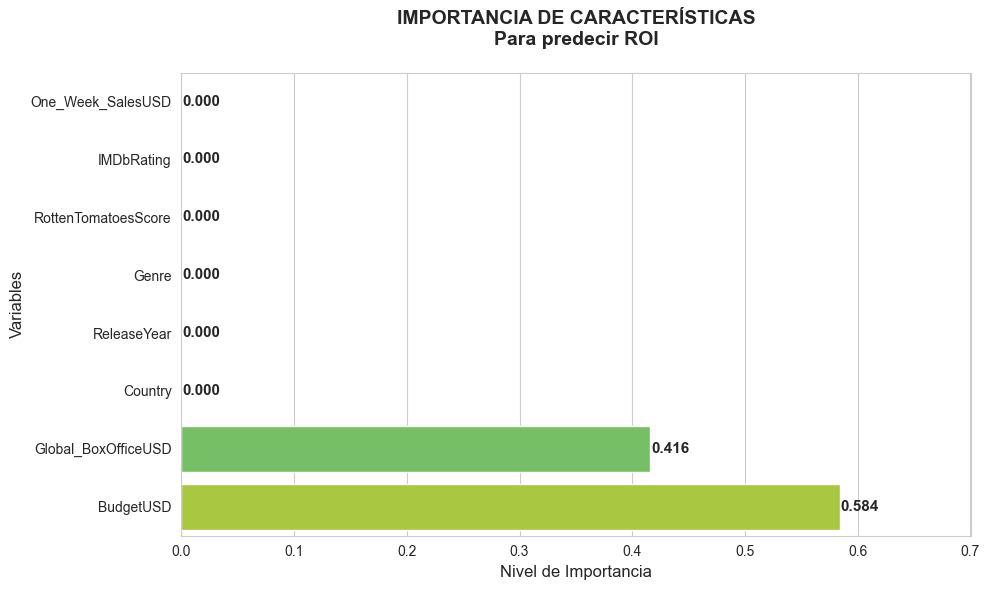

In [8]:


potential_features = [
    "BudgetUSD", "One_Week_SalesUSD", "IMDbRating", "RottenTomatoesScore",
    "Genre", "Country", "ReleaseYear", "Global_BoxOfficeUSD"
]

# Filtrar solo las que existen en el dataset
features = [f for f in potential_features if f in df.columns]
print(f" Variables encontradas: {features}")

if len(features) < 2:
    print(" Error: Se necesitan al menos 2 variables para el analisis")
else:
    # 2. DEFINIR VARIABLE OBJETIVO
    print("\n2. DEFINIR VARIABLE OBJETIVO...")
    
    if 'ROI' in df.columns:
        y = df["ROI"]
        target_name = "ROI"
        print(" Variable objetivo: ROI")
    elif 'Global_BoxOfficeUSD' in df.columns:
        y = df["Global_BoxOfficeUSD"] 
        target_name = "Global_BoxOfficeUSD"
        print(" Variable objetivo: Global_BoxOfficeUSD")
    else:
        # Si no hay ninguna, usar la primera numerica que no sea predictor
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        possible_targets = [col for col in numeric_cols if col not in features]
        if possible_targets:
            y = df[possible_targets[0]]
            target_name = possible_targets[0]
            print(f" Variable objetivo por defecto: {target_name}")
        else:
            print("Error: No se encontro variable objetivo adecuada")
            y = None
    
    if y is not None:
        # 3. DEFINIR X (variables predictoras)
        X = df[features]
        print(f"\n3. DATOS DEFINIDOS:")
        print(f"   X (predictoras): {X.shape}")
        print(f"   y (objetivo): {y.shape}")
        
        # 4. LIMPIEZA DE DATOS
        print("\n4. LIMPIANDO DATOS...")
        
        # Crear copias para no modificar el original
        X_clean = X.copy()
        y_clean = y.copy()
        
        # Manejar valores nulos
        for col in X_clean.columns:
            if X_clean[col].isnull().sum() > 0:
                if X_clean[col].dtype in ['float64', 'int64']:
                    X_clean[col].fillna(X_clean[col].median(), inplace=True)
                    print(f"    {col}: nulos reemplazados con mediana")
                else:
                    X_clean[col].fillna(X_clean[col].mode()[0], inplace=True)
                    print(f"    {col}: nulos reemplazados con moda")
        
        # Manejar valores infinitos
        for col in X_clean.select_dtypes(include=[np.number]).columns:
            if np.isinf(X_clean[col]).sum() > 0:
                X_clean[col] = X_clean[col].replace([np.inf, -np.inf], np.nan)
                X_clean[col].fillna(X_clean[col].median(), inplace=True)
                print(f"   {col}: infinitos corregidos")
        
        # Limpiar variable objetivo
        if y_clean.isnull().sum() > 0:
            y_clean.fillna(y_clean.median(), inplace=True)
            print(f"   y: nulos reemplazados con mediana")
        
        if np.isinf(y_clean).sum() > 0:
            y_clean = y_clean.replace([np.inf, -np.inf], np.nan)
            y_clean.fillna(y_clean.median(), inplace=True)
            print(f"    y: infinitos corregidos")
        
        print("\n5. DIVIDIENDO DATOS...")
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=0.2, random_state=42
        )
        
        print(f"   • Train: {X_train.shape[0]} muestras")
        print(f"   • Test: {X_test.shape[0]} muestras")
        
        # 6. ENTRENAR MODELO
      
        try:
            modelo = DecisionTreeRegressor(
                random_state=42,
                max_depth=5,
                min_samples_split=10,
                min_samples_leaf=5
            )
            modelo.fit(X_train, y_train)
            print(" Modelo entrenado exitosamente")
            
            # 7. OBTENER IMPORTANCIA
            importancia = modelo.feature_importances_
            importancia_df = pd.DataFrame({
                'Variable': X_clean.columns,
                'Importancia': importancia
            }).sort_values('Importancia', ascending=True)
            
            print(f"\n IMPORTANCIA DE CARACTERÍSTICAS:")
            for _, row in importancia_df.iterrows():
                print(f"   • {row['Variable']}: {row['Importancia']:.3f}")
            
            # 8. VISUALIZAR
            plt.figure(figsize=(10, 6))
            sns.set_style("whitegrid")
            
            barplot = sns.barplot(
                data=importancia_df,
                y='Variable', 
                x='Importancia',
                palette='viridis'
            )
            
            # Añadir valores en las barras
            for i, valor in enumerate(importancia_df['Importancia']):
                plt.text(valor + 0.001, i, f"{valor:.3f}", va='center', fontsize=11, fontweight='bold')
            
            plt.title(f'IMPORTANCIA DE CARACTERÍSTICAS\nPara predecir {target_name}', 
                     fontsize=14, fontweight='bold', pad=20)
            plt.xlabel('Nivel de Importancia', fontsize=12)
            plt.ylabel('Variables', fontsize=12)
            plt.xlim(0, max(importancia) * 1.2)
            plt.tight_layout()
            plt.show()

            
        except Exception as e:
            print(f"  Error en el entrenamiento: {e}")
            print(" Intentando con configuración más simple...")
            
            # Fallback: modelo super simple
            modelo_simple = DecisionTreeRegressor(random_state=42, max_depth=3)
            modelo_simple.fit(X_train, y_train)
            
            importancia_simple = modelo_simple.feature_importances_
            print(" Modelo simple - Importancia:")
            for feat, imp in zip(features, importancia_simple):
                print(f"   • {feat}: {imp:.3f}")

In [9]:
print("1. DEFINICION DE VARIABLES:")

features = ["BudgetUSD", "One_Week_SalesUSD"] 
target = "ROI" if "ROI" in df.columns else "Global_BoxOfficeUSD"

features = [f for f in features if f in df.columns]
if target not in df.columns:
    print(f" Error: Variable objetivo '{target}' no encontrada")

    possible_targets = [col for col in df.columns if 'BoxOffice' in col or 'ROI' in col]
    if possible_targets:
        target = possible_targets[0]
        print(f" Usando variable objetivo alternativa: {target}")
    else:
        print(" No se encontro variable objetivo adecuada")

print(f"   Predictoras: {features}")
print(f"   Objetivo: {target}")

if len(features) > 0 and target in df.columns:
    # 2. TRAIN - TEST (80% - 20%)
    print("\n2. PRIMERA DIVISION: TRAIN - TEST (80% - 20%)")
    
    X = df[features]
    y = df[target]
    
    # Limpieza basica
    X = X.fillna(X.median())
    y = y.fillna(y.median())
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=True
    )
    
    print(" Primera division completada:")
    print(f"   • X_train: {X_train.shape}")
    print(f"   • X_test:  {X_test.shape}")
    print(f"   • Proporcion: {len(X_train)/len(X)*100:.1f}% train, {len(X_test)/len(X)*100:.1f}% test")
    
    # 3. TRAIN - VALIDATION (80% - 20% del train)
    print("\n3. TRAIN - VALIDATION")
    
    X_train2, X_val, y_train2, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, shuffle=True
    )
    
    print(" Segunda division completada:")
    print(f"   • X_train2: {X_train2.shape} (entrenamiento final)")
    print(f"   • X_val:    {X_val.shape} (validación)")
    print(f"   • X_test:   {X_test.shape} (test final)")
    
    # 4. RESUMEN FINAL
    print("\n4. RESUMEN:")
    total_final = len(X_train2) + len(X_val) + len(X_test)
    
    print(f"   • Entrenamiento (Train2): {len(X_train2)} muestras ({len(X_train2)/total_final*100:.1f}%)")
    print(f"   • Validacion:             {len(X_val)} muestras ({len(X_val)/total_final*100:.1f}%)")
    print(f"   • Test:                   {len(X_test)} muestras ({len(X_test)/total_final*100:.1f}%)")
    print(f"   • TOTAL:                  {total_final} muestras")
    
    # 5. GUARDAR ARCHIVOS 
    print("\n5. GUARDANDO ARCHIVOS CSV...")
    
    # Crear carpeta si no existe
    os.makedirs('../Datos/preparados', exist_ok=True)
    
    # Guardar todos los archivos requeridos
    X_train2.to_csv('../Datos/preparados/TrainX.csv', index=False)
    y_train2.to_csv('../Datos/preparados/TrainY.csv', index=False)
    X_val.to_csv('../Datos/preparados/ValidationX.csv', index=False)
    y_val.to_csv('../Datos/preparados/ValidationY.csv', index=False)
    X_test.to_csv('../Datos/preparados/TestX.csv', index=False)
    y_test.to_csv('../Datos/preparados/TestY.csv', index=False)
    
    archivos = ['TrainX.csv', 'TrainY.csv', 'ValidationX.csv', 'ValidationY.csv', 'TestX.csv', 'TestY.csv']
    for archivo in archivos:
        ruta = f'../Datos/preparados/{archivo}'
        if os.path.exists(ruta):
            df_check = pd.read_csv(ruta)
            print(f"   • {archivo}: {df_check.shape}")

1. DEFINICION DE VARIABLES:
   Predictoras: ['BudgetUSD', 'One_Week_SalesUSD']
   Objetivo: ROI

2. PRIMERA DIVISION: TRAIN - TEST (80% - 20%)
 Primera division completada:
   • X_train: (576376, 2)
   • X_test:  (144095, 2)
   • Proporcion: 80.0% train, 20.0% test

3. TRAIN - VALIDATION
 Segunda division completada:
   • X_train2: (461100, 2) (entrenamiento final)
   • X_val:    (115276, 2) (validación)
   • X_test:   (144095, 2) (test final)

4. RESUMEN:
   • Entrenamiento (Train2): 461100 muestras (64.0%)
   • Validacion:             115276 muestras (16.0%)
   • Test:                   144095 muestras (20.0%)
   • TOTAL:                  720471 muestras

5. GUARDANDO ARCHIVOS CSV...
   • TrainX.csv: (461100, 2)
   • TrainY.csv: (461100, 1)
   • ValidationX.csv: (115276, 2)
   • ValidationY.csv: (115276, 1)
   • TestX.csv: (144095, 2)
   • TestY.csv: (144095, 1)
